# Week 3: CNN Overfitting and Data Augmentation

In this week, I trained a Convolutional Neural Network (CNN) on the CIFAR-10 dataset and observed the effects of overfitting. Overfitting occurs when a model learns the training data very well but performs poorly on unseen data. This happens because the model memorizes patterns specific to the training dataset instead of learning general features that can be applied to new images.

To address overfitting, I used data augmentation. Data augmentation artificially increases the diversity of the training dataset by applying random transformations such as horizontal flipping, rotations, shifts, and zooming. These transformations create new variations of existing images without collecting additional data.

The experiments showed a clear difference between the baseline model and the augmented model. The baseline model achieved very high training accuracy but had a noticeable gap between training and validation accuracy, indicating overfitting. After applying augmentation, training accuracy increased more slowly, but validation and test performance improved. This demonstrates that data augmentation helps the model generalize better to unseen images and reduces overfitting.

The key lesson from this week is that improving model performance is not always about making the network larger. Sometimes providing more diverse training examples is more effective than increasing model complexity.

Imports

In [32]:
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Dense,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D,
    RandomFlip,
    RandomRotation,
    RandomZoom,
    RandomContrast
)
from tensorflow.keras.models import Model

Load Dataset

In [33]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training Images:", x_train.shape)
print("Test Images:", x_test.shape)

Training Images: (50000, 32, 32, 3)
Test Images: (10000, 32, 32, 3)


Normalize

In [34]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

Data Augmentation

In [35]:
data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1),
    RandomContrast(0.1)
])

Build CNN

In [36]:
inputs = Input(shape=(32, 32, 3))

x = data_augmentation(inputs)

# Block 1
x = Conv2D(32, (3,3), padding="same", activation="relu")(x)
x = BatchNormalization()(x)

x = Conv2D(32, (3,3), padding="same", activation="relu")(x)
x = BatchNormalization()(x)

x = MaxPooling2D()(x)

# Block 2
x = Conv2D(64, (3,3), padding="same", activation="relu")(x)
x = BatchNormalization()(x)

x = Conv2D(64, (3,3), padding="same", activation="relu")(x)
x = BatchNormalization()(x)

x = MaxPooling2D()(x)

# Block 3
x = Conv2D(128, (3,3), padding="same", activation="relu")(x)
x = BatchNormalization()(x)

x = Conv2D(128, (3,3), padding="same", activation="relu")(x)
x = BatchNormalization()(x)

x = MaxPooling2D()(x)

# Classification
x = GlobalAveragePooling2D()(x)

x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)

outputs = Dense(10, activation="softmax")(x)

model = Model(inputs, outputs)

Compile

In [37]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

View Model

In [38]:
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 324,394 (1.24 MB)

 Trainable params: 323,498 (1.23 MB)

 Non-trainable params: 896 (3.50 KB)

Train

In [39]:
history = model.fit(
    x_train,
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.4341 - loss: 1.5647 - val_accuracy: 0.5436 - val_loss: 1.2679
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.5667 - loss: 1.2129 - val_accuracy: 0.5958 - val_loss: 1.1262
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.6315 - loss: 1.0527 - val_accuracy: 0.6795 - val_loss: 0.9161
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.6724 - loss: 0.9444 - val_accuracy: 0.6324 - val_loss: 1.1439
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.6976 - loss: 0.8726 - val_accuracy: 0.6934 - val_loss: 0.9083
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.7188 - loss: 0.8169 - val_accuracy: 0.6889 - val_loss: 0.8862
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.7369 - loss: 0.7710 - val_accuracy: 0.7278 - val_loss: 0.7763
Epoch 8/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.7483 - loss: 0.7299 - 

Plot Accuracy

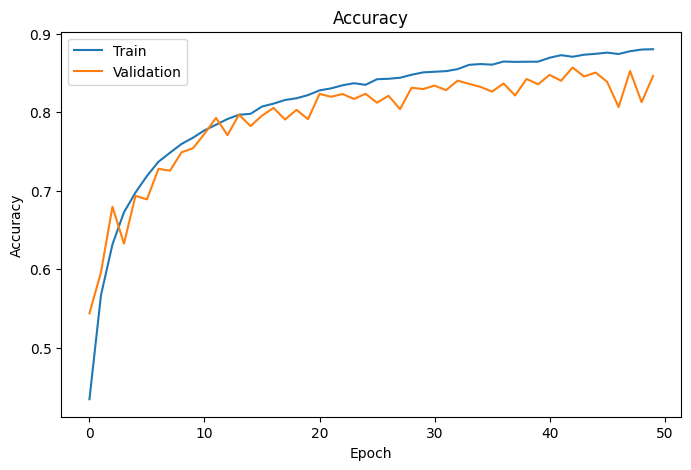

In [40]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])

plt.show()

Plot Loss

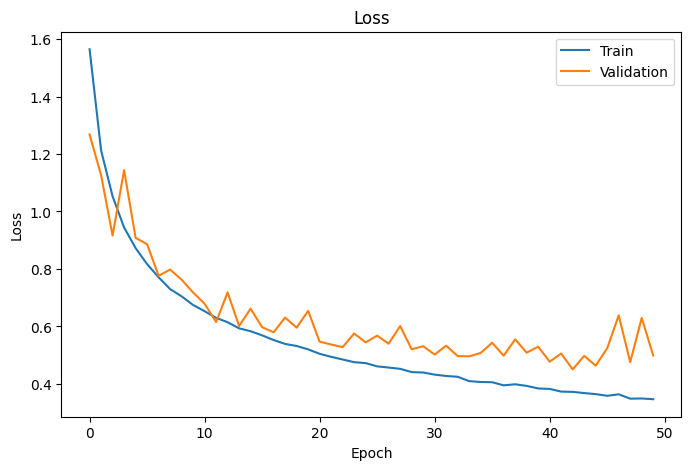

In [41]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])

plt.show()

Test Accuracy

In [42]:
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy =", round(test_acc * 100, 2), "%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8331 - loss: 0.5416
Test Accuracy = 83.31 %


Show Augmentations

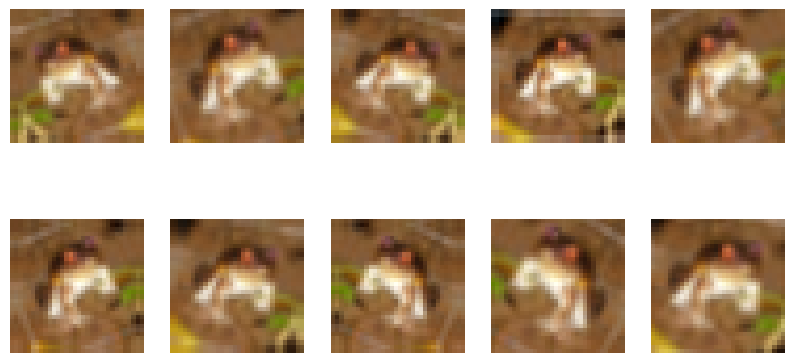

In [47]:
sample_image = x_train[0]

plt.figure(figsize=(10,5))

for i in range(10):
    augmented = data_augmentation(
        tf.expand_dims(sample_image, axis=0)
    )

    plt.subplot(2,5,i+1)
    plt.imshow(augmented[0])
    plt.axis("off")

plt.show()

# Final Results

| Model | Training Accuracy | Validation Accuracy | Test Accuracy | Parameters |
|---------|------------------|-------------------|--------------|------------|
| Baseline CNN | 98.08% | 71.35% | 70.8% | 361,898 |
| Augmented CNN | 88.03% | 84.62% | 83.31% | 324,394 |

### Observation

The augmented model achieved lower training accuracy but higher validation and test accuracy. This indicates better generalization and reduced overfitting.